Initial Data Shape: (15, 13)

Model Performance:
MAE: 12790.531115515061
RMSE: 15149.060334313544
R2 Score: 0.8585310780058871


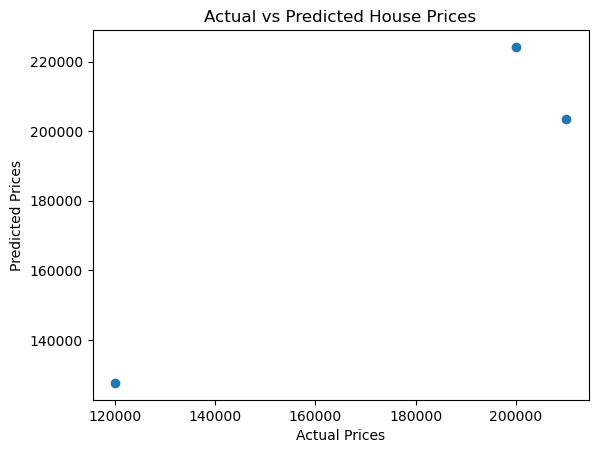

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler

# Load dataset
df = pd.read_csv("train.csv")

print("Initial Data Shape:", df.shape)

# -------------------------------
# DATA PREPROCESSING
# -------------------------------

# Drop columns with too many missing values
df = df.drop(columns=['Alley', 'PoolQC', 'Fence', 'MiscFeature'], errors='ignore')

# Fill missing values
df = df.fillna(df.median(numeric_only=True))

# Convert categorical variables using one-hot encoding
df = pd.get_dummies(df, drop_first=True)

# -------------------------------
# FEATURE SELECTION
# -------------------------------

X = df.drop("SalePrice", axis=1)
y = df["SalePrice"]

# -------------------------------
# TRAIN-TEST SPLIT
# -------------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# -------------------------------
# FEATURE SCALING
# -------------------------------

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# -------------------------------
# MODEL TRAINING
# -------------------------------

model = LinearRegression()
model.fit(X_train, y_train)

# -------------------------------
# PREDICTIONS
# -------------------------------

y_pred = model.predict(X_test)

# -------------------------------
# EVALUATION
# -------------------------------

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("\nModel Performance:")
print("MAE:", mae)
print("RMSE:", rmse)
print("R2 Score:", r2)

# -------------------------------
# VISUALIZATION
# -------------------------------

plt.figure()
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.title("Actual vs Predicted House Prices")
plt.show()